In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1 (Data Cleaning)

In [3]:
df=pd.read_csv('2) Stock Prices Data Set.csv')
df_backup=df.copy()
df

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916


In [4]:
df.isnull().sum()
df.loc[[188547,188578,188760],'open']=df.loc[[188547,188578,188760],'open'].fillna(df[['close','high','low']].mean(axis=1))
df['open']=df['open'].ffill()
df = df.loc[~((df['volume'] == 0) & (df['high'].isna()))]
df[df.isna().any(axis=1)]
df['high']=df['high'].fillna(df[['open','close']].max(axis=1))
df['low']=df['low'].fillna(df[['open','close']].min(axis=1))

C:\Users\ISRATUN NAHAR\AppData\Local\Temp\ipykernel_17396\1623363017.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['high']=df['high'].fillna(df[['open','close']].max(axis=1))
C:\Users\ISRATUN NAHAR\AppData\Local\Temp\ipykernel_17396\1623363017.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['low']=df['low'].fillna(df[['open','close']].min(axis=1))


In [5]:
df = df.reset_index()

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df.dropna(subset=['date'])  

df = df.sort_values('date')

df = df.set_index('date')

In [6]:
df.duplicated().sum()
df

,index,symbol,open,high,low,close,volume
date,,,,,,,
2014-01-02,0,AAL,25.07,25.82,25.060,25.36,8998943
2014-01-02,330,NVDA,15.92,15.98,15.720,15.86,6502296
2014-01-02,329,NUE,53.29,53.38,52.510,52.73,1611326
2014-01-02,328,NTRS,61.76,61.95,60.665,60.89,1011050
2014-01-02,327,NTAP,41.01,41.01,40.415,40.42,2427140
...,...,...,...,...,...,...,...
2017-12-29,497128,EMR,70.04,70.21,69.690,69.69,1848874
2017-12-29,497127,EMN,93.71,93.76,92.550,92.64,632351
2017-12-29,497126,EL,127.80,128.13,127.200,127.24,805149


# Task 2 (Exploratory Data Analysis) + Task 3 (Basic Data Visualization)

In [7]:
df["Month"]=df.index.month
df["Year"]=df.index.year
df.resample('ME').mean(numeric_only=True).round(2)

,index,open,high,low,close,volume,Month,Year
date,,,,,,,,
2014-01-31,5071.00,71.90,72.55,71.18,71.83,4954678.77,1.0,2014.0
2014-02-28,14731.00,72.69,73.52,72.05,72.86,4918514.59,2.0,2014.0
2014-03-31,24392.50,75.06,75.68,74.27,74.90,4424685.90,3.0,2014.0
2014-04-30,34552.00,74.73,75.41,73.80,74.58,4712436.74,4.0,2014.0
2014-05-31,44731.00,75.22,75.88,74.61,75.32,3755789.42,5.0,2014.0
2014-06-30,54918.50,77.72,78.32,77.17,77.83,3688931.00,6.0,2014.0
2014-07-31,65359.50,78.69,79.26,78.04,78.64,3886941.26,7.0,2014.0
2014-08-31,75819.00,78.27,78.86,77.72,78.35,3277133.95,8.0,2014.0
2014-09-30,86048.50,79.10,79.66,78.44,79.04,3729642.81,9.0,2014.0


In [8]:
df['return'] = df['close']-df['open']
df['range'] = df['high'] - df['low']

df

,index,symbol,open,high,low,close,volume,Month,Year,return,range
date,,,,,,,,,,,
2014-01-02,0,AAL,25.07,25.82,25.060,25.36,8998943,1,2014,0.29,0.760
2014-01-02,330,NVDA,15.92,15.98,15.720,15.86,6502296,1,2014,-0.06,0.260
2014-01-02,329,NUE,53.29,53.38,52.510,52.73,1611326,1,2014,-0.56,0.870
2014-01-02,328,NTRS,61.76,61.95,60.665,60.89,1011050,1,2014,-0.87,1.285
2014-01-02,327,NTAP,41.01,41.01,40.415,40.42,2427140,1,2014,-0.59,0.595
...,...,...,...,...,...,...,...,...,...,...,...
2017-12-29,497128,EMR,70.04,70.21,69.690,69.69,1848874,12,2017,-0.35,0.520
2017-12-29,497127,EMN,93.71,93.76,92.550,92.64,632351,12,2017,-1.07,1.210
2017-12-29,497126,EL,127.80,128.13,127.200,127.24,805149,12,2017,-0.56,0.930


In [9]:
df['volume'].corr(df['return'])

np.float64(-0.007129462686381428)

In [10]:
mean=df[['open','high','low','close','volume']].mean()
median=df[['open','high','low','close','volume']].median()
std=df[['open','high','low','close']].std()
print("Mean:\n", mean)
print("\nMedian:\n", median)
print("\nStandard Deviation:\n", std)

Mean:
 open      8.635190e+01
high      8.713343e+01
low       8.555226e+01
close     8.636931e+01
volume    4.253645e+06
dtype: float64

Median:
 open           64.97
high           65.56
low            64.35
close          64.98
volume    2084948.00
dtype: float64

Standard Deviation:
 open     101.470579
high     102.313566
low      100.570587
close    101.472771
dtype: float64


<Axes: xlabel='return', ylabel='Count'>

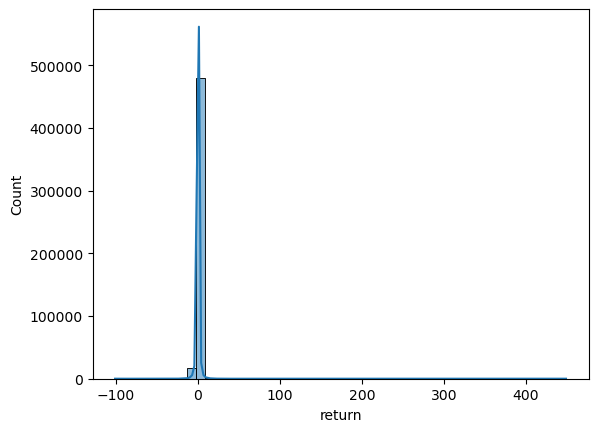

In [11]:
sns.histplot(df['return'], bins=50, kde=True)

<Axes: >

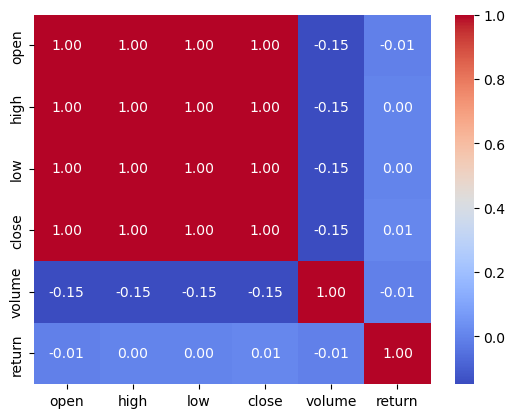

In [12]:
sns.heatmap(df[['open','high','low','close','volume','return']].corr(), annot=True, cmap='coolwarm', fmt=".2f")

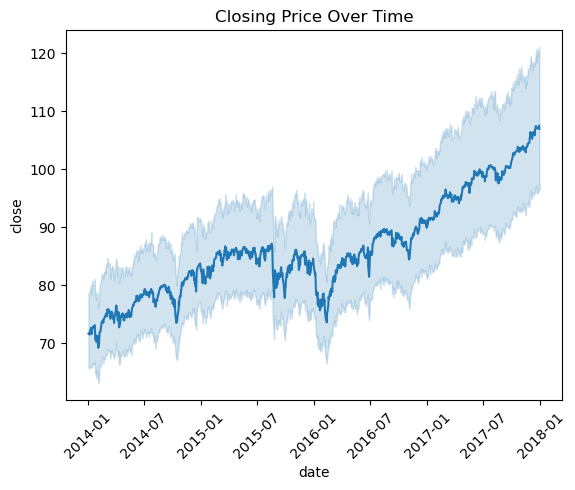

In [13]:
sns.lineplot(x=df.index, y='close', data=df)
plt.title('Closing Price Over Time')
plt.xticks(rotation=45)
plt.show()

# Task 1 (regression Analysis)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = df[['open', 'high', 'low', 'volume']]
y = df['close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

result=pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(result.head())

Mean Squared Error: 0.5139059726679766
R-squared: 0.9999478527823
Coefficients: [-5.98620438e-01  8.53813215e-01  7.44284361e-01 -5.11150235e-10]
Intercept: -0.007549921898885259
            Actual   Predicted
date                          
2015-12-14   54.16   54.013986
2017-08-10   30.51   30.810396
2016-10-03   99.75   99.791581
2016-02-22  125.01  124.801163
2016-08-09   54.49   55.043297


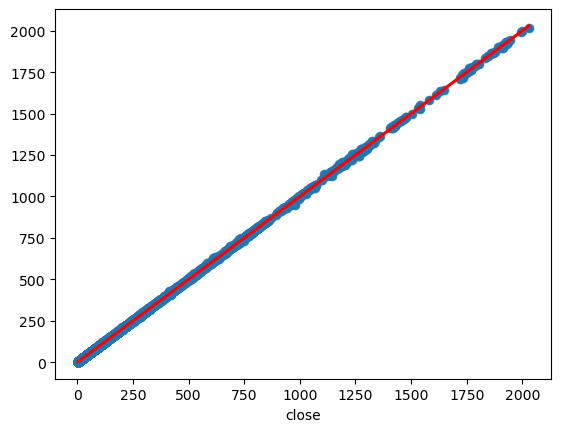

In [15]:
sns.scatterplot(x=y_test, y=y_pred)
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
plt.show()

In [16]:
df=df.rename(columns={'return':'returns','range':'price_range'})
df

,index,symbol,open,high,low,close,volume,Month,Year,returns,price_range
date,,,,,,,,,,,
2014-01-02,0,AAL,25.07,25.82,25.060,25.36,8998943,1,2014,0.29,0.760
2014-01-02,330,NVDA,15.92,15.98,15.720,15.86,6502296,1,2014,-0.06,0.260
2014-01-02,329,NUE,53.29,53.38,52.510,52.73,1611326,1,2014,-0.56,0.870
2014-01-02,328,NTRS,61.76,61.95,60.665,60.89,1011050,1,2014,-0.87,1.285
2014-01-02,327,NTAP,41.01,41.01,40.415,40.42,2427140,1,2014,-0.59,0.595
...,...,...,...,...,...,...,...,...,...,...,...
2017-12-29,497128,EMR,70.04,70.21,69.690,69.69,1848874,12,2017,-0.35,0.520
2017-12-29,497127,EMN,93.71,93.76,92.550,92.64,632351,12,2017,-1.07,1.210
2017-12-29,497126,EL,127.80,128.13,127.200,127.24,805149,12,2017,-0.56,0.930


In [17]:
df["returns"].sum()

np.float64(8658.652166666669)

In [18]:
from sqlalchemy import create_engine

username='root'
password='5656'
host='localhost'
port='3306'
database='stock'
engine=create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

table_name="price"
df.to_sql(table_name, con=engine, if_exists='replace', index=True)
pd.read_sql("Select * from price LIMIT 5;", con=engine )

,date,index,symbol,open,high,low,close,volume,Month,Year,returns,price_range
0,2014-01-02,0,AAL,25.07,25.82,25.060,25.36,8998943,1,2014,0.29,0.760
1,2014-01-02,330,NVDA,15.92,15.98,15.720,15.86,6502296,1,2014,-0.06,0.260
2,2014-01-02,329,NUE,53.29,53.38,52.510,52.73,1611326,1,2014,-0.56,0.870
3,2014-01-02,328,NTRS,61.76,61.95,60.665,60.89,1011050,1,2014,-0.87,1.285
4,2014-01-02,327,NTAP,41.01,41.01,40.415,40.42,2427140,1,2014,-0.59,0.595
